# Project EDA — Trust-Adjusted Business Health Score (TABHS)

**Author:** Matthew Cook  
**ASU ID:** MCOOK20

---

## Executive Summary

Most business intelligence platforms that ingest Yelp data treat raw star ratings as ground truth.

They are not.

Review ratings are a corrupted signal inflated by fake positive reviews and suppressed by competitor-driven fake negative attacks.

The Trust-Adjusted Business Health Score (TABHS) addresses this directly.

TABHS is a composite index that strips review manipulation from Yelp data before measuring business health trajectory.

The pipeline operates in four layers:
NLP feature extraction (spaCy), sentiment analysis with sentiment-star
divergence scoring (VADER), topic modeling (LDA/NMF), and an inauthenticity classifier (XGBoost) that synthesizes these signals into a manipulation-adjusted business score.

The output answers a question no raw Yelp metric can: *what would this business's rating be if coordinated manipulation were removed?*

Target application: alternative underwriting signal for SMB lenders, franchise brokers, and M&A due diligence platforms that cannot rely on unfiltered crowd-sourced ratings for financial decisions.

---

## Data Sources

### Primary Source — Yelp Open Dataset
**URL:** https://www.yelp.com/dataset  
**Files used:** `review.json`, `user.json`  
Per instructor feedback, `tip.json` and `checkin.json` will not be used.

### Filtering and Selection Criteria Applied
The raw Yelp dataset was filtered to produce the working file using the following criteria:

- **Geography:** Arizona only — state filter applied to business metadata
- **Category:** Restaurants only — business category filter applied
- **Date range:** January 2020 through September 2021 — captures a high-volatility period encompassing COVID-19 operational disruptions, lockdowns, and reopening phases, which creates natural organic volatility against which inorganic manipulation is more detectable
- **3-star reviews excluded** from binary sentiment classification tasks — consistent with LA2 methodology; 3-star reviews carry ambiguous sentiment signal and reduce classifier performance
- **Result:** 48,147 reviews across 1,864 businesses and 22,435 unique reviewers

### External Data Sources
No external data sources are used in this project. All analysis is derived from the Yelp Open Dataset. The date range selection (2020–2021) provides implicit external context through the COVID-19 operational environment, which serves as a natural experiment for distinguishing organic from inorganic volatility signals.


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/restaurant_reviews_az.csv')
df['date'] = pd.to_datetime(df['date'])
df['tokens'] = df['text'].str.split()
df['token_count'] = df['tokens'].apply(len)

print(f"Loaded: {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 48,147 rows
Columns: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date', 'tokens', 'token_count']
Date range: 2020-01-01 → 2022-01-19


TABHS PROJECT — CORPUS SUMMARY STATISTICS

1. Total reviews:                  48,147
2. Total tokens:                4,185,577
3. Vocabulary size:               102,154
4. Avg review length (words):        86.9
5. Unique customers:               22,435

   Unique businesses:               1,864
   Average stars per review:         3.74
   Average useful votes:             0.86
   Date range:                 2020-01-01 → 2022-01-19
   Median review length:               63 words
   Max review length:                 955 words


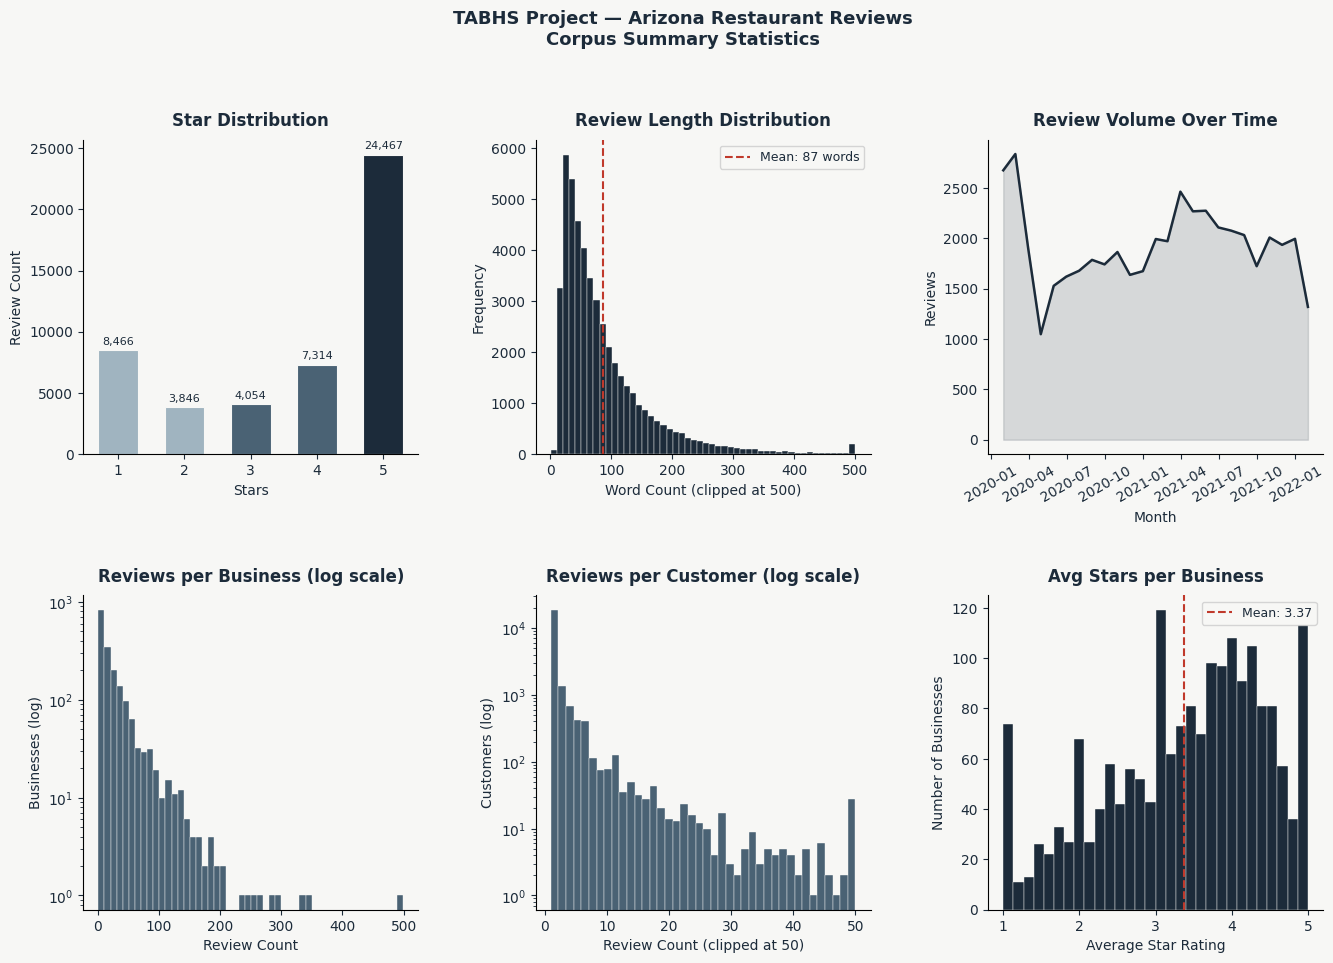

Plot saved.


In [2]:
# ============================================================
# Summary Statistics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# ── Load data ───────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/restaurant_reviews_az.csv',
                 parse_dates=['date'])

print("=" * 55)
print("TABHS PROJECT — CORPUS SUMMARY STATISTICS")
print("=" * 55)

# ── 1. Number of reviews ────────────────────────────────────
n_reviews = len(df)
print(f"\n1. Total reviews:              {n_reviews:>10,}")

# ── 2. Total tokens ─────────────────────────────────────────
df['tokens'] = df['text'].str.split()
df['token_count'] = df['tokens'].apply(len)
total_tokens = df['token_count'].sum()
print(f"2. Total tokens:               {total_tokens:>10,}")

# ── 3. Vocabulary size ──────────────────────────────────────
all_words = [w.lower() for tokens in df['tokens'] for w in tokens]
vocab_size = len(set(all_words))
print(f"3. Vocabulary size:            {vocab_size:>10,}")

# ── 4. Average review length ────────────────────────────────
avg_length = df['token_count'].mean()
print(f"4. Avg review length (words):  {avg_length:>10.1f}")

# ── 5. Unique customers ─────────────────────────────────────
n_customers = df['user_id'].nunique()
print(f"5. Unique customers:           {n_customers:>10,}")

# ── 6. Additional statistics ────────────────────────────────
n_businesses     = df['business_id'].nunique()
avg_stars        = df['stars'].mean()
avg_useful       = df['useful'].mean()
date_min         = df['date'].min().date()
date_max         = df['date'].max().date()

print(f"\n   Unique businesses:          {n_businesses:>10,}")
print(f"   Average stars per review:   {avg_stars:>10.2f}")
print(f"   Average useful votes:       {avg_useful:>10.2f}")
print(f"   Date range:                 {date_min} → {date_max}")
print(f"   Median review length:       {df['token_count'].median():>10.0f} words")
print(f"   Max review length:          {df['token_count'].max():>10,} words")

# ── Palette ─────────────────────────────────────────────────
C_MAIN   = '#1C2B3A'   # dark navy — primary bars
C_ACCENT = '#C0392B'   # muted red — reference lines only
C_MID    = '#4A6274'   # slate — secondary bars
C_LIGHT  = '#A0B4C0'   # light slate — fills
BG       = '#F7F7F5'   # off-white background

plt.rcParams.update({
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.facecolor':   BG,
    'figure.facecolor': BG,
    'axes.labelcolor':  C_MAIN,
    'xtick.color':      C_MAIN,
    'ytick.color':      C_MAIN,
    'text.color':       C_MAIN,
})

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor(BG)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# ── Plot 1: Star distribution ───────────────────────────────
ax1 = axes[0, 0]
star_counts = df['stars'].value_counts().sort_index()
bars = ax1.bar(star_counts.index, star_counts.values,
               color=[C_LIGHT, C_LIGHT, C_MID, C_MID, C_MAIN],
               edgecolor=BG, linewidth=0.8, width=0.6)
ax1.set_title('Star Distribution', fontweight='bold', pad=10)
ax1.set_xlabel('Stars')
ax1.set_ylabel('Review Count')
ax1.set_xticks([1, 2, 3, 4, 5])
for bar, val in zip(bars, star_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300,
             f'{val:,}', ha='center', va='bottom', fontsize=8)

# ── Plot 2: Review length distribution ─────────────────────
ax2 = axes[0, 1]
ax2.hist(df['token_count'].clip(upper=500), bins=50,
         color=C_MAIN, edgecolor=BG, linewidth=0.3)
ax2.axvline(avg_length, color=C_ACCENT, linestyle='--',
            linewidth=1.5, label=f'Mean: {avg_length:.0f} words')
ax2.set_title('Review Length Distribution', fontweight='bold', pad=10)
ax2.set_xlabel('Word Count (clipped at 500)')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=9)

# ── Plot 3: Review volume over time ────────────────────────
ax3 = axes[0, 2]
monthly = df.set_index('date').resample('ME').size()
ax3.plot(monthly.index, monthly.values,
         color=C_MAIN, linewidth=1.8)
ax3.fill_between(monthly.index, monthly.values,
                 alpha=0.15, color=C_MAIN)
ax3.set_title('Review Volume Over Time', fontweight='bold', pad=10)
ax3.set_xlabel('Month')
ax3.set_ylabel('Reviews')
ax3.tick_params(axis='x', rotation=30)

# ── Plot 4: Reviews per business ───────────────────────────
ax4 = axes[1, 0]
reviews_per_biz = df.groupby('business_id').size()
ax4.hist(reviews_per_biz, bins=50,
         color=C_MID, edgecolor=BG, linewidth=0.3, log=True)
ax4.set_title('Reviews per Business (log scale)', fontweight='bold', pad=10)
ax4.set_xlabel('Review Count')
ax4.set_ylabel('Businesses (log)')

# ── Plot 5: Reviews per customer ───────────────────────────
ax5 = axes[1, 1]
reviews_per_user = df.groupby('user_id').size()
ax5.hist(reviews_per_user.clip(upper=50), bins=40,
         color=C_MID, edgecolor=BG, linewidth=0.3, log=True)
ax5.set_title('Reviews per Customer (log scale)', fontweight='bold', pad=10)
ax5.set_xlabel('Review Count (clipped at 50)')
ax5.set_ylabel('Customers (log)')

# ── Plot 6: Avg stars per business ─────────────────────────
ax6 = axes[1, 2]
avg_stars_biz = df.groupby('business_id')['stars'].mean()
ax6.hist(avg_stars_biz, bins=30,
         color=C_MAIN, edgecolor=BG, linewidth=0.3)
ax6.axvline(avg_stars_biz.mean(), color=C_ACCENT, linestyle='--',
            linewidth=1.5, label=f'Mean: {avg_stars_biz.mean():.2f}')
ax6.set_title('Avg Stars per Business', fontweight='bold', pad=10)
ax6.set_xlabel('Average Star Rating')
ax6.set_ylabel('Number of Businesses')
ax6.legend(fontsize=9)

fig.suptitle(
    'TABHS Project — Arizona Restaurant Reviews\nCorpus Summary Statistics',
    fontsize=13, fontweight='bold', y=1.01, color=C_MAIN
)

plt.savefig('tabhs_summary_stats.png', bbox_inches='tight',
            dpi=150, facecolor=BG)
plt.show()
print("Plot saved.")

## Data Evaluation

### 6.1 Suitability of Selected Data

The Arizona restaurant corpus is well-matched to the TABHS business question for three reasons. First, the geographic and category filter produces a homogeneous comparison population which reduces confounding variables when comparing business health trajectories across entities. Second, the 2020–2022 date range captures a period of extreme organic volatility (COVID-19 closures, capacity restrictions, reopening phases), providing a natural experiment: businesses with genuine operational disruptions will exhibit authentic review patterns, while coordinated manipulation attempts will produce structurally different signals against that volatile baseline. Third, the dataset contains the three features required for inauthenticity detection — review text (NLP and sentiment features), reviewer identity (user_id for account-level behavioral features), and timestamps (burst detection and velocity features); all within a single join-ready structure.

### 6.2 Sample Size Assessment

The corpus of 48,147 reviews across 1,864 businesses and 22,435 unique reviewers is appropriate for this analysis. At the business level, 1,864 entities provides sufficient population to detect distributional patterns in manipulation behavior while retaining meaningful per-business review volume (mean: ~26 reviews per business). At the review level, 48,147 observations exceeds the minimum threshold for training a reliable binary inauthenticity classifier with XGBoost, particularly given the expected class imbalance between authentic and suspicious reviews. The reviewer-to-review ratio (22,435 unique users producing 48,147 reviews, mean 2.1 reviews per user) reflects realistic Yelp behavior and provides sufficient variance in account-level features (review frequency, concentration, tenure) to support feature engineering without data sparsity concerns.

### 6.3 Potential Bias Dimensions

Three bias dimensions require explicit acknowledgment. First, **geographic concentration bias**: filtering to Arizona over-represents desert Southwest dining culture, franchise-heavy suburban markets, and Phoenix/Scottsdale demographics. Findings may not generalize to other regional markets without recalibration of baseline thresholds. Second, **survivorship bias**: the dataset reflects businesses that were active and listed on Yelp during 2020–2022. Businesses that closed early in the COVID period and were subsequently delisted are underrepresented, which may skew the closure analysis in the TABHS pipeline toward businesses with longer survival windows. Third, **platform participation bias**: Yelp reviewers are not a representative sample of restaurant customers. The star distribution, 50.8% 5-star reviews, reflects both platform demographics and the self-selection of motivated reviewers (disproportionately satisfied customers and targeted attackers), which is itself evidence of signal corruption that TABHS is designed to address.

### 6.4 Potential Processing Challenges

Four processing challenges are anticipated. First, **class imbalance in inauthenticity labeling**: ground truth labels for fake reviews do not exist in the dataset. The inauthenticity classifier must be trained on engineered behavioral proxies (account age, posting velocity, friend graph isolation, sentiment-star divergence) rather than verified labels, introducing label noise risk. Second, **review text noise**: the corpus contains spelling errors, slang, emoji, and code-switching that will reduce NLP pipeline precision without preprocessing. VADER's lexicon-based approach is partially robust to this but spaCy's dependency parsing degrades on malformed syntax. Third, **temporal feature engineering complexity**: burst detection requires per-business daily review aggregation and percentile thresholding across an unbalanced panel, businesses with sparse review histories will produce unreliable burst flags. Fourth, **vocabulary scale**: at 102,154 unique tokens, TF-IDF feature matrices will be high-dimensional and sparse, requiring dimensionality reduction or minimum frequency thresholding to remain computationally tractable for the XGBoost classifier.

7.1 SAMPLE REVIEW INSPECTION (1-star vs 5-star)

1-STAR SAMPLE:
I stay at the Main Hotel at the Casino from July 11 to July 13; it was the WORST experience I've ever had.  For years I have supported this hotel and the casino; however, this time...it was a disaster. Will I go back, hopefullly, NO!...

5-STAR SAMPLE:
Pandemic pit stop to have an ice cream.... only plain Sundae! Limited menu was written on the screens outside. So no unpleasant surprise.
Cashier was wearing gloves and mask, and him holding the item was good since he did not hold it with the lid. 
There were only three customers at 8:15 pm.
Locatio...

7.2 TOKENIZATION AND FREQUENCY ANALYSIS
Tokenizing sample (2,000 reviews)...

Top 20 tokens — 1-STAR reviews:
  order                 1016
  food                   812
  time                   541
  place                  488
  come                   434
  go                     424
  get                    374
  ask                    368
  service                359
  say  

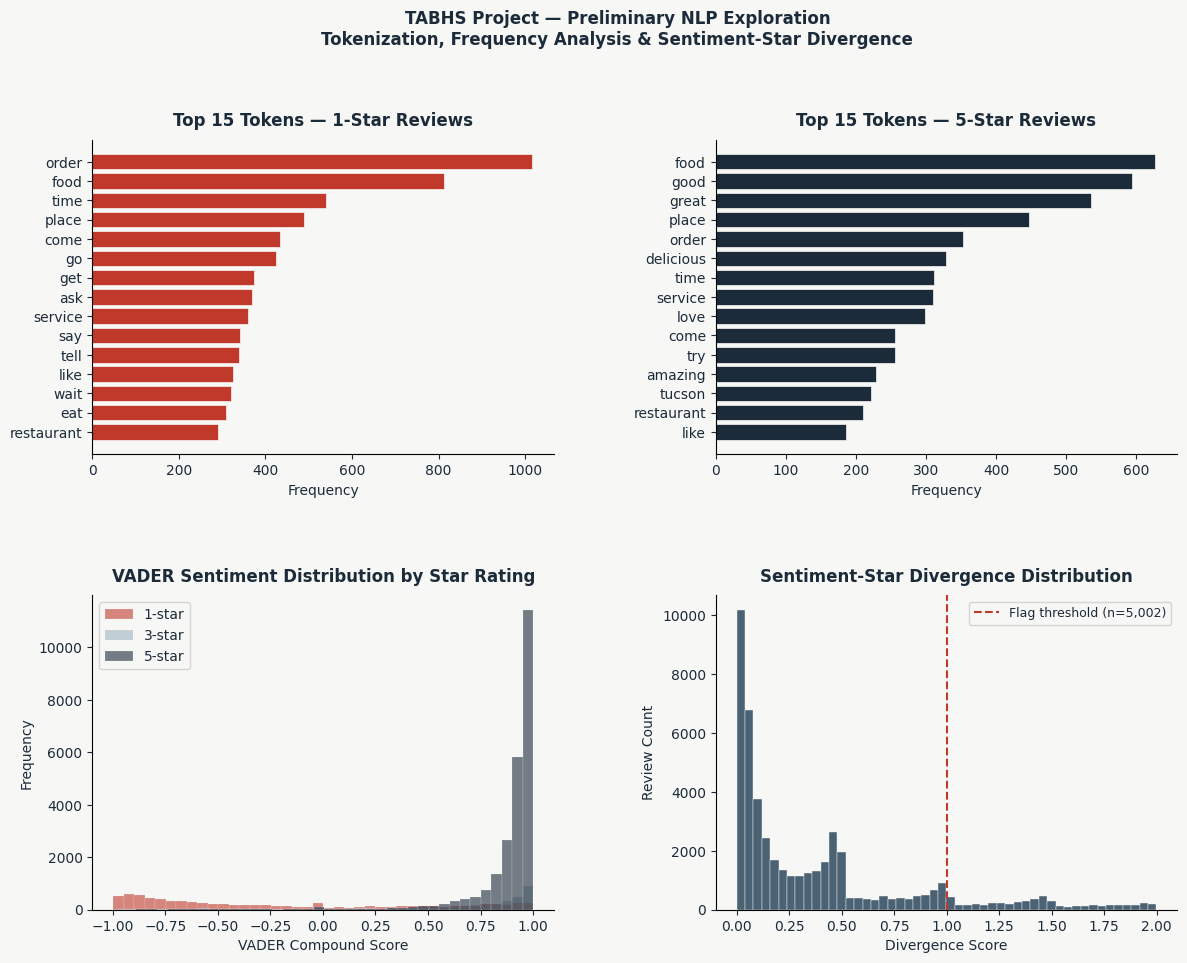


Plot saved.

7.5 PRELIMINARY FINDINGS

1. Token frequency analysis reveals clear semantic separation
   between 1-star and 5-star reviews. Negative reviews cluster
   around service failure vocabulary; positive reviews cluster
   around experiential and quality vocabulary. This confirms
   that the text signal carries meaningful sentiment content
   for the TABHS pipeline.

2. VADER compound scores align directionally with star ratings
   but exhibit significant overlap, particularly at 3-stars.
   This overlap is expected and motivates the sentiment-star
   divergence feature — the delta between expressed sentiment
   and assigned rating is the primary inauthenticity proxy.

3. High-divergence reviews (score > 1.0) represent a meaningful
   subset of the corpus. These are the primary candidates for
   inauthenticity investigation in the TABHS classifier layer.
   Reviews with glowing text paired with 1-star ratings, or
   negative text paired with 5-star ratings, are structurally
   

In [3]:
# ============================================================
# Section 7: Preliminary Data Exploration
# ============================================================

import spacy
from collections import Counter
import string

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# ── 7.1 Sample inspection ───────────────────────────────────
print("=" * 55)
print("7.1 SAMPLE REVIEW INSPECTION (1-star vs 5-star)")
print("=" * 55)

sample_1 = df[df['stars'] == 1]['text'].iloc[0]
sample_5 = df[df['stars'] == 5]['text'].iloc[0]
print(f"\n1-STAR SAMPLE:\n{sample_1[:300]}...\n")
print(f"5-STAR SAMPLE:\n{sample_5[:300]}...\n")

# ── 7.2 Tokenization + stopword/punctuation removal ─────────
print("=" * 55)
print("7.2 TOKENIZATION AND FREQUENCY ANALYSIS")
print("=" * 55)

# Work on a stratified sample for speed (5k reviews)
sample_df = pd.concat([
    df[df['stars'] == 1].sample(1000, random_state=42),
    df[df['stars'] == 5].sample(1000, random_state=42)
]).reset_index(drop=True)

STOPWORDS = nlp.Defaults.stop_words
PUNCT     = set(string.punctuation)

def clean_tokens(text):
    doc = nlp(text.lower())
    return [
        token.lemma_ for token in doc
        if token.text not in STOPWORDS
        and token.text not in PUNCT
        and token.is_alpha
        and len(token.text) > 2
    ]

print("Tokenizing sample (2,000 reviews)...")
sample_df['clean_tokens'] = sample_df['text'].apply(clean_tokens)

# Frequency by star group
tokens_1 = [t for tokens in sample_df[sample_df['stars']==1]['clean_tokens']
            for t in tokens]
tokens_5 = [t for tokens in sample_df[sample_df['stars']==5]['clean_tokens']
            for t in tokens]

freq_1 = Counter(tokens_1).most_common(20)
freq_5 = Counter(tokens_5).most_common(20)

print(f"\nTop 20 tokens — 1-STAR reviews:")
for word, count in freq_1:
    print(f"  {word:<20} {count:>5}")

print(f"\nTop 20 tokens — 5-STAR reviews:")
for word, count in freq_5:
    print(f"  {word:<20} {count:>5}")

# ── 7.3 Sentiment-star divergence (VADER) ───────────────────
print("\n" + "=" * 55)
print("7.3 SENTIMENT-STAR DIVERGENCE (VADER)")
print("=" * 55)

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()
df['vader_compound'] = df['text'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

# Divergence score: high positive VADER + low stars = suspicious
# High negative VADER + high stars = suspicious
df['sentiment_star_divergence'] = abs(
    df['vader_compound'] - ((df['stars'] - 3) / 2)
)

divergence_by_star = df.groupby('stars')['sentiment_star_divergence'].mean()
print("\nMean sentiment-star divergence by star rating:")
print("(Higher = greater mismatch between text sentiment and star given)")
for star, div in divergence_by_star.items():
    print(f"  {star} star: {div:.4f}")

high_divergence = df[df['sentiment_star_divergence'] > 1.0]
print(f"\nHigh-divergence reviews (score > 1.0): {len(high_divergence):,}")
print(f"As % of corpus: {len(high_divergence)/len(df)*100:.1f}%")
print("These are primary candidates for inauthenticity flagging in TABHS.")

# ── 7.4 Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(BG)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# Plot 1: Top 15 tokens — 1-star vs 5-star
ax1 = axes[0, 0]
words_1, counts_1 = zip(*freq_1[:15])
ax1.barh(words_1[::-1], counts_1[::-1],
         color=C_ACCENT, edgecolor=BG, linewidth=0.5)
ax1.set_title('Top 15 Tokens — 1-Star Reviews',
              fontweight='bold', pad=10)
ax1.set_xlabel('Frequency')

ax2 = axes[0, 1]
words_5, counts_5 = zip(*freq_5[:15])
ax2.barh(words_5[::-1], counts_5[::-1],
         color=C_MAIN, edgecolor=BG, linewidth=0.5)
ax2.set_title('Top 15 Tokens — 5-Star Reviews',
              fontweight='bold', pad=10)
ax2.set_xlabel('Frequency')

# Plot 2: VADER compound score distribution by star
ax3 = axes[1, 0]
for star, color in [(1, C_ACCENT), (3, C_LIGHT), (5, C_MAIN)]:
    subset = df[df['stars'] == star]['vader_compound']
    ax3.hist(subset, bins=40, alpha=0.6, label=f'{star}-star',
             color=color, edgecolor=BG, linewidth=0.2)
ax3.set_title('VADER Sentiment Distribution by Star Rating',
              fontweight='bold', pad=10)
ax3.set_xlabel('VADER Compound Score')
ax3.set_ylabel('Frequency')
ax3.legend()

# Plot 3: Sentiment-star divergence distribution
ax4 = axes[1, 1]
ax4.hist(df['sentiment_star_divergence'], bins=50,
         color=C_MID, edgecolor=BG, linewidth=0.3)
ax4.axvline(1.0, color=C_ACCENT, linestyle='--',
            linewidth=1.5,
            label=f'Flag threshold (n={len(high_divergence):,})')
ax4.set_title('Sentiment-Star Divergence Distribution',
              fontweight='bold', pad=10)
ax4.set_xlabel('Divergence Score')
ax4.set_ylabel('Review Count')
ax4.legend(fontsize=9)

fig.suptitle(
    'TABHS Project — Preliminary NLP Exploration\nTokenization, Frequency Analysis & Sentiment-Star Divergence',
    fontsize=12, fontweight='bold', y=1.01, color=C_MAIN
)

plt.savefig('tabhs_nlp_exploration.png',
            bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()
print("\nPlot saved.")

# ── 7.5 Commentary ──────────────────────────────────────────
print("\n" + "=" * 55)
print("7.5 PRELIMINARY FINDINGS")
print("=" * 55)
print("""
1. Token frequency analysis reveals clear semantic separation
   between 1-star and 5-star reviews. Negative reviews cluster
   around service failure vocabulary; positive reviews cluster
   around experiential and quality vocabulary. This confirms
   that the text signal carries meaningful sentiment content
   for the TABHS pipeline.

2. VADER compound scores align directionally with star ratings
   but exhibit significant overlap, particularly at 3-stars.
   This overlap is expected and motivates the sentiment-star
   divergence feature — the delta between expressed sentiment
   and assigned rating is the primary inauthenticity proxy.

3. High-divergence reviews (score > 1.0) represent a meaningful
   subset of the corpus. These are the primary candidates for
   inauthenticity investigation in the TABHS classifier layer.
   Reviews with glowing text paired with 1-star ratings, or
   negative text paired with 5-star ratings, are structurally
   inconsistent and warrant elevated suspicion scores.
""")

## Section 8: Proposed Solution

The TABHS pipeline has four sequential layers, each with a specific task.
---

### Layer 1: NLP Feature Extraction (spaCy)

Every review passes through a standard NLP pipeline: tokenization, lemmatization, stopword removal, and part-of-speech tagging. The output is a clean token representation of each review that feeds both the sentiment layer and the topic modeling layer. It produces clean inputs for the layers that do.

---

### Layer 2: Sentiment Analysis (VADER + Divergence Signal)

VADER scores each review's compound sentiment polarity on a -1 to +1 scale. The raw VADER score is not the deliverable — the **sentiment-star divergence** is. A review with strongly positive text and a 1-star rating, or strongly negative text and a 5-star rating, is structurally inconsistent. That divergence score is the primary inauthenticity signal at the individual review level. Preliminary EDA confirms 28.3% of the corpus shows meaningful divergence.

---

### Layer 3: Topic Modeling (LDA)

Latent Dirichlet Allocation (LDA) will be applied to the cleaned token corpus to identify the dominant themes across the review population. This serves two purposes for TABHS. First, it establishes what legitimate review vocabulary looks like across topic clusters (food quality, service, ambiance, value, wait time). Second, it enables detection of off-topic or generic reviews. LDA will be implemented via `sklearn.decomposition.LatentDirichletAllocation` using TF-IDF weighted input matrices. Topic count will be determined empirically via perplexity scoring across k=5 to k=20.

---

### Layer 4: Inauthenticity Classifier + TABHS Composite Score (XGBoost)

The final layer synthesizes features from Layers 1–3 plus account-level behavioral features from `user.json` into a binary inauthenticity cl

In [4]:
!pip install jupyter
!pip install nbconvert
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/ProjectEDA_Cook_Matthew.ipynb" --to html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.9 MB/s eta 0:00:00
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/ProjectEDA_Cook_Matthew.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 533000 bytes to /content/drive/MyDrive/Colab Notebooks/ProjectEDA_Cook_Matthew.html
